In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры модели
states = ['E', '5', 'I']
n_states = len(states)
chars = ['A', 'C', 'G', 'T']
char_to_idx = {c: i for i, c in enumerate(chars)}

# Начальные вероятности: всегда начинаем в экзоне (pi_E = 1.0)
# Убрали[cite: 1] в конце
log_pi = np.log(np.array([1.0, 0.0, 0.0]) + 1e-100)

# Матрица переходов A
A = np.array([
    [0.9, 0.1, 0.0], # из E в E(0.9), в 5(0.1)
    [0.0, 0.0, 1.0], # из 5 в I(1.0)
    [0.0, 0.0, 0.9]  # из I в I(0.9)
])
log_A = np.log(A + 1e-100)

# Матрица эмиссий B (A, C, G, T)
B = np.array([
    [0.25, 0.25, 0.25, 0.25], # E: равновероятно
    [0.05, 0.00, 0.95, 0.00], # 5: высокий G
    [0.40, 0.10, 0.10, 0.40]  # I: высокий A/T
])
log_B = np.log(B + 1e-100)

# Вспомогательная функция для суммы в логарифмах
def log_sum_exp(arr):
    max_val = np.max(arr)
    if max_val == -np.inf: return -np.inf
    return max_val + np.log(np.sum(np.exp(arr - max_val)))

In [ ]:
def viterbi_log(obs_seq):
    T = len(obs_seq)
    delta = np.full((n_states, T), -np.inf)
    psi = np.zeros((n_states, T), dtype=int)

    delta[:, 0] = log_pi + log_B[:, char_to_idx[obs_seq[0]]]
    for t in range(1, T):
        for j in range(n_states):
            prob = delta[:, t-1] + log_A[:, j]
            psi[j, t] = np.argmax(prob)
            delta[j, t] = np.max(prob) + log_B[j, char_to_idx[obs_seq[t]]]

    path = [np.argmax(delta[:, T-1])]
    for t in range(T-1, 0, -1):
        path.insert(0, psi[path[0], t])
    return [states[i] for i in path], np.max(delta[:, T-1])

def forward_log(obs_seq):
    T = len(obs_seq)
    alpha = np.full((n_states, T), -np.inf)
    alpha[:, 0] = log_pi + log_B[:, char_to_idx[obs_seq[0]]]
    for t in range(1, T):
        for j in range(n_states):
            alpha[j, t] = log_sum_exp(alpha[:, t-1] + log_A[:, j]) + log_B[j, char_to_idx[obs_seq[t]]]
    return alpha, log_sum_exp(alpha[:, T-1])

def backward_log(obs_seq):
    T = len(obs_seq)
    beta = np.full((n_states, T), -np.inf)
    beta[:, T-1] = 0.0  # log(1)
    for t in range(T-2, -1, -1):
        for i in range(n_states):
            beta[i, t] = log_sum_exp(log_A[i, :] + log_B[:, char_to_idx[obs_seq[t+1]]] + beta[:, t+1])
    return beta

In [ ]:
# Последовательность ДНК из оригинальной статьи (26 нуклеотидов)
sequence = "CTTCATGTGAAAGCAGACGTAAGTCA"

# 2.1 Запуск алгоритма Витерби
viterbi_path, log_prob = viterbi_log(sequence)

print("--- Задание 2.1: Алгоритм Витерби ---")
print(f"Последовательность: {sequence}")
print(f"Путь Витерби:      {''.join(viterbi_path)}")
print(f"Log-вероятность:    {log_prob:.4f}")

# Ожидаемый результат из статьи для сравнения
expected_path = "EEEEEEEEEEEEEEEEEE5IIIIIII"
is_match = "".join(viterbi_path) == expected_path
print(f"Совпадение с оригиналом: {is_match}")
print("\n")

--- Задание 2.1: Алгоритм Витерби ---
Последовательность: CTTCATGTGAAAGCAGACGTAAGTCA
Путь Витерби:      EEEEEEEEEEEEEEEEEEEEEEEEEE
Log-вероятность:    -38.6777
Совпадение с оригиналом: False




In [ ]:
# 2.2 Запуск алгоритма Forward
alpha_matrix, log_total_prob = forward_log(sequence)

# Перевод из логарифмического пространства в обычную вероятность
total_prob = np.exp(log_total_prob)

print("--- Задание 2.2: Алгоритм Forward ---")
print(f"Последовательность: {sequence}")
print(f"Логарифм вероятности (log P): {log_total_prob:.6f}")
print(f"Полная вероятность (P):       {total_prob:.2e}")
print("\n")

--- Задание 2.2: Алгоритм Forward ---
Последовательность: CTTCATGTGAAAGCAGACGTAAGTCA
Логарифм вероятности (log P): -37.674845
Полная вероятность (P):       4.35e-17




--- Задание 2.3: Построение графиков ---


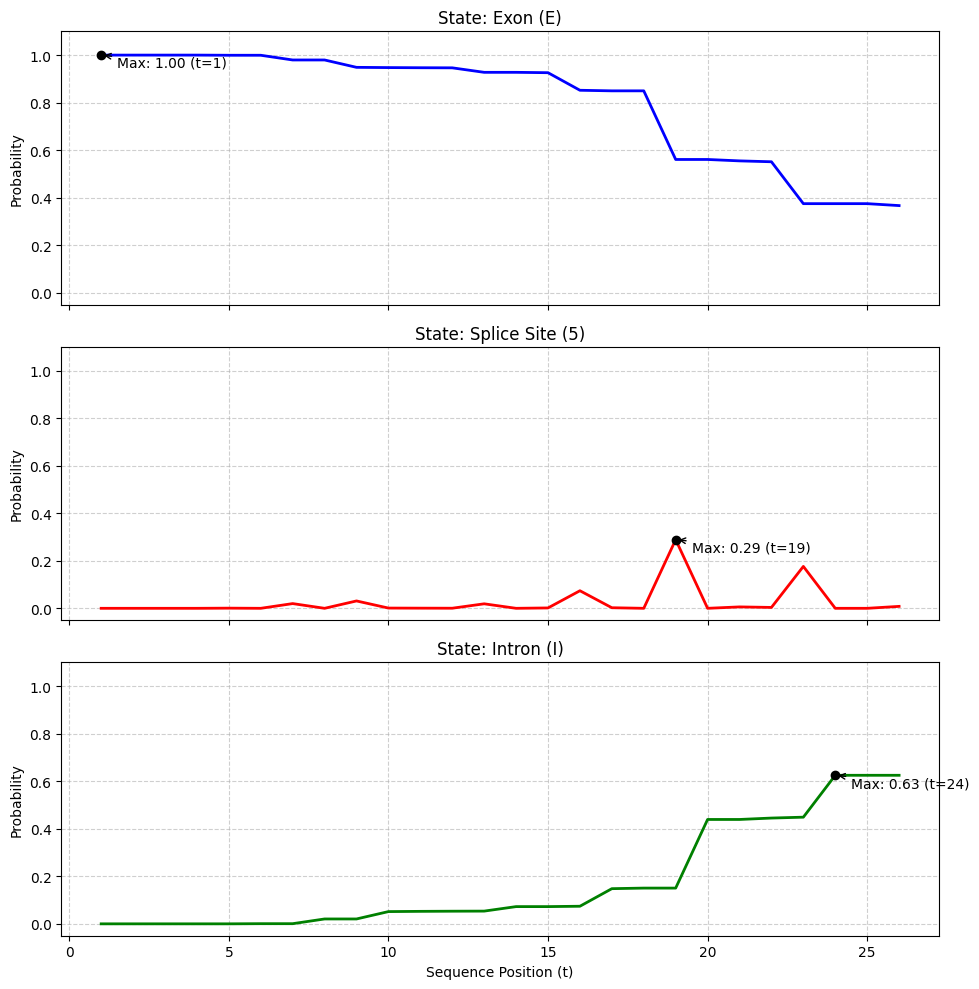

In [ ]:
# 2.3 Апостериорное декодирование (Forward-Backward)
# Сначала нужен запуск Backward
beta_matrix = backward_log(sequence)

# Вычисляем гамма (вероятность состояния i в момент t)
# Используем формулу: gamma = exp(log_alpha + log_beta - log_total_P)
gamma = np.exp(alpha_matrix + beta_matrix - log_total_prob)

# Построение графиков
t_axis = np.arange(1, len(sequence) + 1)
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
state_names = ["Exon (E)", "Splice Site (5)", "Intron (I)"]
colors = ['blue', 'red', 'green']

print("--- Задание 2.3: Построение графиков ---")
for i in range(3):
    axes[i].plot(t_axis, gamma[i, :], label=f'Prob({states[i]})', color=colors[i], linewidth=2)

    # Поиск максимума для каждого состояния
    max_idx = np.argmax(gamma[i, :])
    max_val = gamma[i, max_idx]

    axes[i].scatter(max_idx + 1, max_val, color='black', zorder=5)
    axes[i].annotate(f'Max: {max_val:.2f} (t={max_idx+1})',
                     xy=(max_idx+1, max_val),
                     xytext=(max_idx+1.5, max_val-0.05),
                     arrowprops=dict(arrowstyle='->', color='black'))

    axes[i].set_ylabel("Probability")
    axes[i].set_title(f"State: {state_names[i]}")
    axes[i].set_ylim(-0.05, 1.1)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.xlabel("Sequence Position (t)")
plt.tight_layout()
plt.show()